# PHASE 1: PREPARING THE DATASET

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

successfully saved 5000 samples of data as ds for training and converted into list
successfully saved 5000 samples of data as test_ds for testing converted into list 


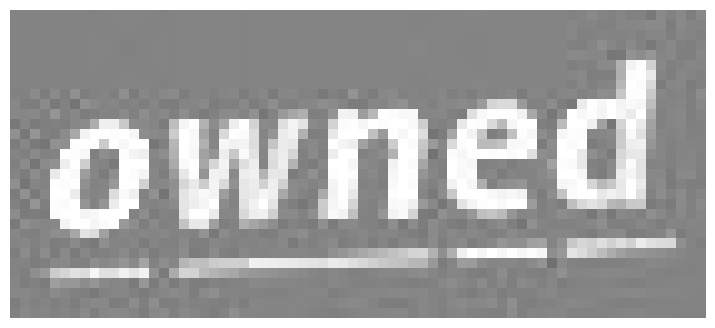

above is the sample of the training dataset


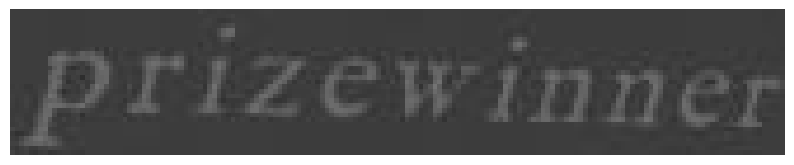

above is the image of the testing dataset
converted successfully in hf dataset
converted into hf datset


In [1]:
#  Loading and preparing the mjsynth dataset 

from datasets import load_dataset
import pprint
from datasets import Dataset
import matplotlib.pyplot as plt


ds = load_dataset(
    "priyank-m/MJSynth_text_recognition",
     split= "train",
     streaming=True
)

test_ds = load_dataset(
    "priyank-m/MJSynth_text_recognition",
     split= "test",
     streaming=True
)

# Inspecting the few samples of train dataset
# for i, sample in enumerate(ds):
#     print("keys", sample.keys())
#     pprint.pprint(sample, depth=2)
#     if i == 2:
#         break

# Streaming 5000 dataset in form of hf dataset and converted in python list
ds = ds.take(5000)
ds = list(ds)
print("successfully saved 5000 samples of data as ds for training and converted into list")

# Streaming 2000 test dataset
test_ds = test_ds.take(2000)
test_ds=list(test_ds)
print("successfully saved 5000 samples of data as test_ds for testing converted into list ")

# Visualizing one image
"""Plot the image in the 10*10 plot
   fig can be used to change the color or save the image 
   ax can be used to make changes in axes""" 
sample = ds[230]
image = sample["image"]
fig, ax = plt.subplots(figsize = (10, 4))
# to plot the image 
ax.imshow(image)
ax.axis('off')
plt.show()
print("above is the sample of the training dataset")

sample2 = test_ds[19]
image_test = sample2["image"]
fig, ax = plt.subplots(figsize =  (10, 4))
ax.imshow(image_test)
ax.axis('off')
plt.show()
print("above is the image of the testing dataset")

# converting into hf dataset
ds=Dataset.from_list(ds)
print("converted successfully in hf dataset")

test_ds=Dataset.from_list(test_ds)
print("converted into hf datset")

In [2]:
# The preprocessing of the mjsynth dataset 
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T
from datasets import load_dataset

# Cleaning the dataset
unique_chars = sorted(list(set("".join(ds["label"])))) # Takes whole row of label feature and extracts the unique characters and stores in form of list.
my_dictionary = {char: idx for idx, char in enumerate(unique_chars, start=1)} # Build the dictionary with index 0 reserved for the CTC token.

# Instantiating a transform pipeline
my_transform_pipeline = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((32, 128)), # (height, width)
    T.ToTensor()
])

# create the custom collection function
class MJSynthDataset(Dataset):
    def __init__(self, ds, char_to_idx_dict, transform):
        super(MJSynthDataset, self).__init__()
        self.ds = ds
        self.char_to_idx_dict = char_to_idx_dict
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, index):
        sample = self.ds[index] # Grabbing a image from the batch(which will be used later)
        image = sample["image"]
        label = sample["label"]

        # convert characters into integers_id
        integer_ids = []
        for char in label:
            char_id = self.char_to_idx_dict.get(char, 0) # 0 is the starting index
            integer_ids.append(char_id)

        label_tensor = torch.tensor(integer_ids, dtype=torch.int64)
        image_tensor = self.transform(image)
        # Return the processed pieces
        return image_tensor, label_tensor


# create collate fn different label tensors sizes and convert them to the same length
# pytorch will hand the batch automatically whatever the getitem returns
def crnn_collate_fn(batch):
    images = []
    labels = []
    labels_length = []

    # unpack the list of tuples 
    for image_tensor, label_tensor in batch:
        images.append(image_tensor)
        labels.append(label_tensor)
        labels_length.append(len(label_tensor))

    images_tensor = torch.stack(images) # This line simply adds images on top of each  
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0) # This line adds filler values to the shorter labels so all the labels same values
    labels_lengths_tensor = torch.tensor(labels_length, dtype=torch.int64) # THis line simply converts the length into tensor objects
    return images_tensor, labels_padded, labels_lengths_tensor


# initialize the dataset class 
dataset = MJSynthDataset (
    ds=ds,
    char_to_idx_dict=my_dictionary,
    transform=my_transform_pipeline
)
print("Dataset object is ready")


# plug it into the train dataLoader
train_dataloader = DataLoader(
    dataset=dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=crnn_collate_fn
)
print("train dataloader is ready")


# creating the test dataloader
test_dataloader = DataLoader(
    dataset=dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=crnn_collate_fn
)

print("test dataloader is ready")

Dataset object is ready
train dataloader is ready
test dataloader is ready


Stacked Images Tensor Shape: torch.Size([8, 1, 32, 128])
Padded Labels Tensor Shape: torch.Size([8, 12])
Lengths Tensor Shape: torch.Size([8])

Original sequence length (before padding): 9
Decoded Tensor Output: TWOPENCES_nothing__nothing__nothing_


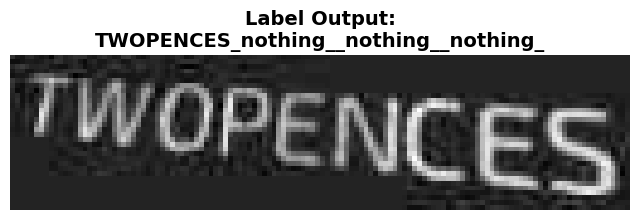

Correct number of classes: 61


In [3]:
# Testing the preprocessed dataset 

import matplotlib.pyplot as plt
import torch

"""The .items() returns a view object which can be can be converted into list or dictionary and char is a tuple 
contain all the keys and idx is the tuple that contains all the values"""
idx_to_char_dict = {idx: char for char, idx in my_dictionary.items()} 
idx_to_char_dict[0] = "_nothing_"

# 2. Grab a single batch of data from your dataloader
# iter() turns the dataloader into an iterator, next() pulls the first batch
images, labels_padded, labels_lengths = next(iter(train_dataloader))

# 3. Print the architecture of the batch to verify collate_fn worked
print(f"Stacked Images Tensor Shape: {images.shape}") # Expected: [32, C, 32, 128]
print(f"Padded Labels Tensor Shape: {labels_padded.shape}") # Expected: [32, max_length_in_this_batch]
print(f"Lengths Tensor Shape: {labels_lengths.shape}") # Expected: [32]

# 4. Extract the very first item in the batch
image_0 = images[0]
label_0 = labels_padded[0]
length_0 = labels_lengths[0]

# 5. Decode the padded tensor back into readable text
decoded_text_list = []
for idx in label_0.numpy():
    val = int(idx)
    decoded_text_list.append(idx_to_char_dict[val])
    
decoded_text = "".join(decoded_text_list)
print(f"\nOriginal sequence length (before padding): {length_0}")
print(f"Decoded Tensor Output: {decoded_text}")

# 6. Set up the matplotlib plot to visually check the image
# PyTorch images are [Channels, Height, Width]. Matplotlib wants [Height, Width, Channels]
image_to_plot = image_0.permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 3))
# If it's a 1-channel grayscale image, squeeze it for matplotlib
if image_to_plot.shape[-1] == 1:
    plt.imshow(image_to_plot.squeeze(), cmap='gray')
else:
    plt.imshow(image_to_plot)

plt.title(f"Label Output:\n{decoded_text}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

TRUE_NUM_CLASSES = len(idx_to_char_dict) 
print(f"Correct number of classes: {TRUE_NUM_CLASSES}")

#  Phase 2 BUILDING THE TEXT RECOGNIZER: 

**Overview of this phase**: 
This CNN architecture will take a cropped image of a word and extract its visual features, condensing it into a feature map.
Unlike standard CNNs which compress both height and width equally, OCR CNN compress height but preserve the width as much as possible.

WHY?
BECAUSE: this ensures the resulting feature map is a wide sequence allowing the other layers can read the word from left to right 

Work in the OCR feature extractor class 
1. added convolution layer( more info are in the group mit paper and medium article) 
2. added batch normalization
3. added rectified linear activation
3. added a pooling layer: In this layer the kernal moves scans 2 rows and and 2 columns outputs the maximum value goes to the next 2x2 part of the matrix does this to entire input.
4. added 4 residual block with pooling layer with each block


This are just bunch of layer being added through which the input image will be passed.

In [4]:
# Building the CNN feature extractor 

import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module): # this class has inherited the class module in file nn
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)      
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = F.relu(out)        
        return out


class OCRFeatureExtractor(nn.Module):
    def __init__(self, input_channels=1):
        super(OCRFeatureExtractor, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.layer1 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.layer2 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.layer3 = ResidualBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)         
        x = self.pool1(x)
        x = self.layer1(x)
        x = self.pool2(x)
        x = self.layer2(x)
        x = self.pool3(x)
        x = self.layer3(x)
        x = self.pool4(x)
        return x

print("done")

done


In [5]:
# Integrating a Sequence model (LSTM) and Building the whole CRNN model

"""input_channels defines channel of the input data.
   Hidden_size refers number of neurons/nodes inside hidden layer so it can learn 256 distinct features. 
   num_layers refers to the number of hidden layers stacked on top of each other.
   num_classes is the number of categories the outputs layer can predict  
"""

class CRNN(nn.Module):
    def __init__(self, input_channels=1, hidden_size=256, num_layers=2, num_classes=TRUE_NUM_CLASSES):
        super(CRNN, self).__init__()
        
        # --- CNN Stage ---
        self.cnn = OCRFeatureExtractor(input_channels)
    
        self.lstm_input_size = 512 * 2  # e.g. 512 * 2 = 1024
    
        # --- NOW layer_norm can use lstm_input_size ---
        self.layer_norm = nn.LayerNorm(self.lstm_input_size)
    
        # --- LSTM Stage ---
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
    
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        batch, channels, height, width = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch, width, channels * height)
        x = self.layer_norm(x) 
        x, _ = self.lstm(x)
        x = self.dropout(x)      
        x = self.fc(x)
        return x

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training pipeline running on device: {device}")

# Assuming model is defined above
model = CRNN(input_channels=1, hidden_size=256, num_layers=2, num_classes=TRUE_NUM_CLASSES)
model = model.to(device)

# 2. Define Hyperparameters
NUM_EPOCHS = 20
BEST_LOSS = float('inf')

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("\n--- Starting Training Loop Pipeline ---")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    model.train() 
    
    running_loss = 0.0
    batch_count = 0
    
    for batch_idx, (images, labels, labels_length) in enumerate(train_dataloader):
        # Move inputs and labels to device (Keep them there!)
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # 3. Forward Pass
        outputs = model(images)

        # PyTorch CTCLoss expects [Time, Batch, Classes]
        outputs = outputs.permute(1, 0, 2)
        
        # 4. Format for CTC Loss Calculation (Removed .cpu() calls)
        log_probs = F.log_softmax(outputs, dim=2)
        
        curr_batch_size = images.size(0)
        time_steps = outputs.size(0) 
        
        # 1D Length tensors (Keeping these on CPU is standard for PyTorch CTC)
        input_lengths = torch.full(size=(curr_batch_size,), fill_value=time_steps, dtype=torch.long)
        target_lengths = labels_length.to(dtype=torch.long)
        
        # 5. Compute Loss & Backpropagate entirely on GPU
        loss = criterion(log_probs, labels, input_lengths, target_lengths)
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Warning: Met NaN/Inf loss at Epoch {epoch+1}, Batch {batch_idx}. Skipping step.")
            continue
            
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        batch_count += 1
        
        # Fixed the NameError here
        if batch_idx % 10 == 0 and batch_idx > 0:
            current_avg = running_loss / batch_count
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Batch [{batch_idx}/{len(train_dataloader)}] | Live CTC Loss: {current_avg:.5f}")

    
    # 6. Epoch Summary
    epoch_duration = time.time() - start_time
    epoch_loss = running_loss / max(1, batch_count)
    
    print(f"\n>> Epoch {epoch+1} Complete | Avg Epoch Loss: {epoch_loss:.5f} | Time Taken: {epoch_duration:.2f}s")
    print("-" * 60)
    
    # 7. Checkpointing
    if epoch_loss < BEST_LOSS:
        BEST_LOSS = epoch_loss
        torch.save(model.state_dict(), "/kaggle/working/best_crnn_ocr_model.pth")
        print(f"Checkpoint saved! New lowest loss achieved: {BEST_LOSS:.5f}\n")

print("\nPipeline Complete! Optimal training model weights exported to 'best_crnn_ocr_model.pth'")

Training pipeline running on device: cuda

--- Starting Training Loop Pipeline ---
Epoch [1/20] | Batch [10/625] | Live CTC Loss: 11.00472
Epoch [1/20] | Batch [20/625] | Live CTC Loss: 8.16475
Epoch [1/20] | Batch [30/625] | Live CTC Loss: 6.92064
Epoch [1/20] | Batch [40/625] | Live CTC Loss: 6.22646
Epoch [1/20] | Batch [50/625] | Live CTC Loss: 5.79123
Epoch [1/20] | Batch [60/625] | Live CTC Loss: 5.48034
Epoch [1/20] | Batch [70/625] | Live CTC Loss: 5.26121
Epoch [1/20] | Batch [80/625] | Live CTC Loss: 5.09094
Epoch [1/20] | Batch [90/625] | Live CTC Loss: 4.97044
Epoch [1/20] | Batch [100/625] | Live CTC Loss: 4.86757
Epoch [1/20] | Batch [110/625] | Live CTC Loss: 4.78495
Epoch [1/20] | Batch [120/625] | Live CTC Loss: 4.71255
Epoch [1/20] | Batch [130/625] | Live CTC Loss: 4.64684
Epoch [1/20] | Batch [140/625] | Live CTC Loss: 4.58973
Epoch [1/20] | Batch [150/625] | Live CTC Loss: 4.54024
Epoch [1/20] | Batch [160/625] | Live CTC Loss: 4.49695
Epoch [1/20] | Batch [170/625

In [7]:
import torch
import torch.nn.functional as F
from torchmetrics.text import CharErrorRate

# 1. Setup Dictionary
idx_to_char_dict = {idx: char for char, idx in my_dictionary.items()}
idx_to_char_dict[0] = "_"

# 2. Decoding Functions
def decode_ctc_predictions(preds, idx_to_char_dict, blank_idx=0):
    strings = []
    for i in range(preds.shape[0]):
        pred_seq = preds[i]
        char_list = []
        for j in range(len(pred_seq)):
            idx = pred_seq[j]
            if idx != blank_idx and (j == 0 or idx != pred_seq[j-1]):
                char_list.append(idx_to_char_dict.get(idx, "?"))
        strings.append("".join(char_list))
    return strings

def decode_labels(labels_padded, labels_length, idx_to_char_dict):
    strings = []
    for i in range(labels_padded.shape[0]):
        seq = labels_padded[i][:labels_length[i]].tolist()
        char_list = []
        for idx in seq:
            if idx != 0:
                char_list.append(idx_to_char_dict.get(idx, "?"))
        strings.append("".join(char_list))
    return strings

# 3. Evaluation Pipeline
def evaluate_text_model_cer():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cer_metric = CharErrorRate()

    print("Loading trained text model...")
    # FIXED: Hardcoded to 61 to match your saved weights exactly
    model = CRNN(input_channels=1, hidden_size=256, num_layers=2, num_classes=61)
    model.to(device)
    model.load_state_dict(torch.load("/kaggle/working/best_crnn_ocr_model.pth", map_location=device))
    
    model.eval()

    all_predictions = []
    all_ground_truths = []

    print("Running inference on test set...")
    with torch.no_grad():
        for images, labels, labels_length in test_dataloader:
            images = images.to(device)

            outputs = model(images)
            log_probs = F.log_softmax(outputs, dim=2)       
            preds = log_probs.argmax(dim=2).cpu().numpy()   

            # FIXED: Removed 'ALPHABET' and passed the correct dictionary variable
            pred_strings = decode_ctc_predictions(preds, idx_to_char_dict=idx_to_char_dict, blank_idx=0)
            gt_strings = decode_labels(labels.cpu(), labels_length.cpu(), idx_to_char_dict)

            all_predictions.extend(pred_strings)
            all_ground_truths.extend(gt_strings)

    final_cer = cer_metric(all_predictions, all_ground_truths)
    
    print(f"\n--- Final Test Evaluation ---")
    print(f"Character Error Rate (CER): {final_cer.item():.4f} ({final_cer.item() * 100:.2f}%)")
    print(f"Accuracy Rate (1 - CER):    {(1 - final_cer.item()) * 100:.2f}%")
    
    print("\n--- Sanity Check (First 5) ---")
    for i in range(min(5, len(all_predictions))):
        print(f"Predicted: {all_predictions[i]:<15} | Actual: {all_ground_truths[i]}")

# Execute the function
evaluate_text_model_cer()

Loading trained text model...
Running inference on test set...

--- Final Test Evaluation ---
Character Error Rate (CER): 0.0185 (1.85%)
Accuracy Rate (1 - CER):    98.15%

--- Sanity Check (First 5) ---
Predicted: MURMURINGS      | Actual: MURMURINGS
Predicted: INFAMOUS        | Actual: INFAMOUS
Predicted: THEMSELVES      | Actual: THEMSELVES
Predicted: ErTing          | Actual: Erring
Predicted: CD              | Actual: CD
